## Ejercicio 1: Evaluación de solicitud de crédito bancario

| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | ingreso_mensual, monto_solicitado, tiene_historial_moroso |
| **Acciones (A)** | aprueba, aprueba con condiciones, rechaza |
| **Entorno (E)** | Sistema de gestión de créditos del banco |
| **Objetivo** | Otorgar préstamos seguros minimizando el riesgo de impago |
| **Medida de desempeño (P)** | Porcentaje de créditos devueltos exitosamente vs tasas de mora |

**Reglas de Decisión y Justificación:**
1. Si el usuario tiene historial moroso o el préstamo supera el 50% de sus ingresos (relacion > 0.5), se rechaza.
2. Si la relación está entre 0.3 y 0.5 sin mora previa, se aprueba con condiciones.
3. Si la relación es menor a 0.3 sin mora, se aprueba directamente.
*Justificación:* Estas reglas son razonables para el banco porque aseguran que el cliente no se sobreendeude (protegiendo el capital) y castigan estrictamente los malos antecedentes financieros para mantener una cartera sana.

## CODIGO

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual
    
    if tiene_historial_moroso or relacion > 0.5:
        return "rechaza", "Riesgo alto: historial moroso o capacidad de pago superada."
    elif relacion >= 0.3 and relacion <= 0.5:
        return "aprueba con condiciones", "Riesgo moderado: nivel de endeudamiento medio."
    else:
        return "aprueba", "Riesgo bajo: excelente capacidad de pago."

## PRUEBAS

In [2]:
pruebas_credito = [
    (3000, 500, False),    # Relación 0.16 -> aprueba
    (3000, 1200, False),   # Relación 0.40 -> aprueba con condiciones
    (3000, 2000, False),   # Relación 0.66 -> rechaza
    (3000, 500, True),     # Moroso -> rechaza
    (5000, 1500, False),   # Relación 0.30 (borde inferior) -> aprueba con condiciones
    (5000, 2500, False)    # Relación 0.50 (borde superior) -> aprueba con condiciones
]

print("--- Pruebas Agente Crédito ---")
for ing, mon, moroso in pruebas_credito:
    accion, motivo = agente_credito(ing, mon, moroso)
    print(f"Ingreso: {ing}, Monto: {mon}, Moroso: {moroso} -> Accion: {accion} ({motivo})")

--- Pruebas Agente Crédito ---
Ingreso: 3000, Monto: 500, Moroso: False -> Accion: aprueba (Riesgo bajo: excelente capacidad de pago.)
Ingreso: 3000, Monto: 1200, Moroso: False -> Accion: aprueba con condiciones (Riesgo moderado: nivel de endeudamiento medio.)
Ingreso: 3000, Monto: 2000, Moroso: False -> Accion: rechaza (Riesgo alto: historial moroso o capacidad de pago superada.)
Ingreso: 3000, Monto: 500, Moroso: True -> Accion: rechaza (Riesgo alto: historial moroso o capacidad de pago superada.)
Ingreso: 5000, Monto: 1500, Moroso: False -> Accion: aprueba con condiciones (Riesgo moderado: nivel de endeudamiento medio.)
Ingreso: 5000, Monto: 2500, Moroso: False -> Accion: aprueba con condiciones (Riesgo moderado: nivel de endeudamiento medio.)


## VISUALIZACION

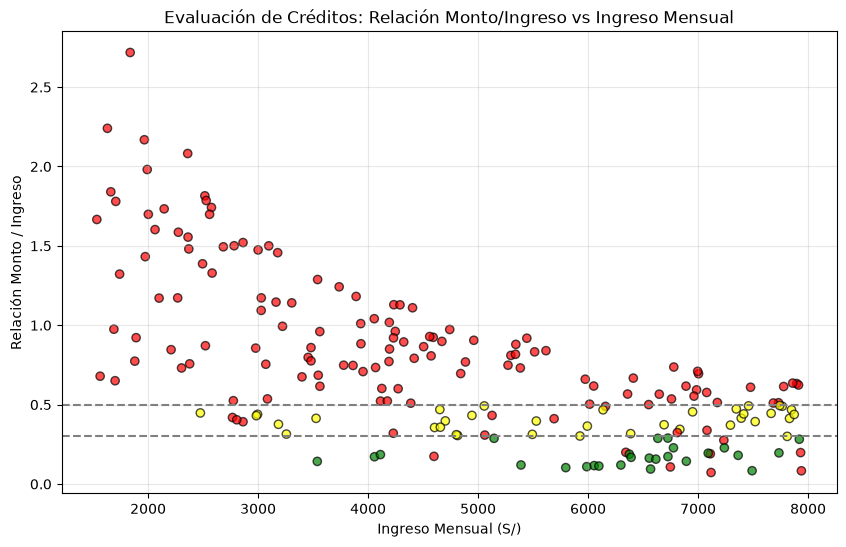

In [3]:
np.random.seed(42)
ingresos = np.random.randint(1500, 8000, 200)
montos = np.random.randint(500, 5000, 200)
historiales = np.random.choice([True, False], 200, p=[0.2, 0.8])

relaciones_plot = []
colores_plot = []
mapa_colores = {"aprueba": "green", "aprueba con condiciones": "yellow", "rechaza": "red"}

for i in range(200):
    accion, _ = agente_credito(ingresos[i], montos[i], historiales[i])
    relaciones_plot.append(montos[i] / ingresos[i])
    colores_plot.append(mapa_colores[accion])

plt.figure(figsize=(10, 6))
plt.scatter(ingresos, relaciones_plot, c=colores_plot, alpha=0.7, edgecolors='k')
plt.title("Evaluación de Créditos: Relación Monto/Ingreso vs Ingreso Mensual")
plt.xlabel("Ingreso Mensual (S/)")
plt.ylabel("Relación Monto / Ingreso")
plt.axhline(y=0.3, color='gray', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

## Ejercicio 2: Escalamiento de tickets de soporte técnico

| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | tiempo_espera_minutos, nivel_urgencia, cliente_premium |
| **Acciones (A)** | escalar a nivel 1, escalar a nivel 2, escalar a nivel 3 |
| **Entorno (E)** | Mesa de ayuda virtual y base de datos de tickets |
| **Objetivo** | Resolver requerimientos técnicos respetando los acuerdos de servicio (SLA) |
| **Medida de desempeño (P)** | Tiempo de respuesta, nivel de satisfacción del usuario |

**Reglas de Decisión y Justificación:**
1. Si el cliente es premium con > 30 min de espera o urgencia es "alta": Nivel 3.
2. Si urgencia es "media" o cliente es premium (espera corta) o espera > 60 min: Nivel 2.
3. Si urgencia es "baja", no es premium y espera <= 60 min: Nivel 1.
*Justificación:* Es razonable porque prioriza a los clientes de mayor valor comercial (premium) y los fallos críticos del sistema para evitar quejas graves, mientras que asigna recursos estándar a problemas menores.

## CODIGO


In [5]:
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    if nivel_urgencia == "alta" or (cliente_premium and tiempo_espera_minutos > 30):
        return "escalar a nivel 3", "Urgencia crítica o cliente VIP con alto tiempo de espera"
    elif nivel_urgencia == "media" or cliente_premium or tiempo_espera_minutos > 60:
        return "escalar a nivel 2", "Urgencia moderada, cliente VIP reciente, o SLA superado"
    else:
        return "escalar a nivel 1", "Soporte estándar para ticket de baja prioridad"

## PRUEBA

In [6]:
pruebas_soporte = [
    (15, "alta", False),   # Nivel 3 por urgencia
    (40, "baja", True),    # Nivel 3 por premium con espera > 30
    (20, "media", False),  # Nivel 2 por urgencia media
    (10, "baja", True),    # Nivel 2 por ser premium (pero poco tiempo)
    (80, "baja", False),   # Nivel 2 porque la espera > 60
    (45, "baja", False)    # Nivel 1, todo estandar
]

print("\n--- Pruebas Agente Soporte ---")
for tiempo, urg, premium in pruebas_soporte:
    accion, motivo = agente_soporte(tiempo, urg, premium)
    print(f"Espera: {tiempo}m, Urgencia: {urg}, Premium: {premium} -> Accion: {accion} ({motivo})")


--- Pruebas Agente Soporte ---
Espera: 15m, Urgencia: alta, Premium: False -> Accion: escalar a nivel 3 (Urgencia crítica o cliente VIP con alto tiempo de espera)
Espera: 40m, Urgencia: baja, Premium: True -> Accion: escalar a nivel 3 (Urgencia crítica o cliente VIP con alto tiempo de espera)
Espera: 20m, Urgencia: media, Premium: False -> Accion: escalar a nivel 2 (Urgencia moderada, cliente VIP reciente, o SLA superado)
Espera: 10m, Urgencia: baja, Premium: True -> Accion: escalar a nivel 2 (Urgencia moderada, cliente VIP reciente, o SLA superado)
Espera: 80m, Urgencia: baja, Premium: False -> Accion: escalar a nivel 2 (Urgencia moderada, cliente VIP reciente, o SLA superado)
Espera: 45m, Urgencia: baja, Premium: False -> Accion: escalar a nivel 1 (Soporte estándar para ticket de baja prioridad)


## Ejercicio 3: Inspección visual de un producto

| Elemento | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz 5x5 de NumPy (0=normal, 1=defectuoso) |
| **Acciones (A)** | aprobar, revisión manual, rechazar |
| **Entorno (E)** | Banda transportadora con cámara industrial |
| **Objetivo** | Asegurar el control de calidad sacando de circulación piezas falladas |
| **Medida de desempeño (P)** | Tasa de defectos detectados y minimización de falsos rechazos |

**Reglas de Decisión y Justificación:**
1. Si tiene 0 defectos: **Aprobar**.
2. Si tiene entre 1 y 3 defectos: **Revisión manual**.
3. Si tiene más de 3 defectos: **Rechazar**.
*Justificación:* Permite automatizar lo obvio (perfectos e inservibles) y solo usa recursos humanos para los casos intermedios (1 a 3 píxeles), optimizando los costos operativos de la fábrica.

## CODIGO

In [7]:
def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = np.sum(imagen)
    
    if defectos == 0:
        return "aprobar", "0 defectos detectados, pieza óptima"
    elif defectos <= 3:
        return "revisión manual", f"Se detectaron {defectos} defecto(s) menores, requiere evaluación"
    else:
        return "rechazar", f"Se detectaron {defectos} defectos, pieza inaceptable"

## PRUEBA

In [8]:
img_perfecta = np.zeros((5,5), dtype=int)

img_borde = np.zeros((5,5), dtype=int)
img_borde[0,0] = 1; img_borde[1,1] = 1; img_borde[2,2] = 1 # 3 defectos

img_rechazo = np.ones((5,5), dtype=int) # Todo defectos

img_intermedia = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
]) # 3 defectos

print("\n--- Pruebas Agente Inspección ---")
print(agente_inspeccion(img_perfecta))
print(agente_inspeccion(img_intermedia))
print(agente_inspeccion(img_borde))
print(agente_inspeccion(img_rechazo))


--- Pruebas Agente Inspección ---
('aprobar', '0 defectos detectados, pieza óptima')
('revisión manual', 'Se detectaron 3 defecto(s) menores, requiere evaluación')
('revisión manual', 'Se detectaron 3 defecto(s) menores, requiere evaluación')
('rechazar', 'Se detectaron 25 defectos, pieza inaceptable')
